In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [3]:
df = pd.read_csv("data/SampleSuperstore.csv")
df.head()
                 

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [5]:
df.shape

(9994, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 17


In [8]:
df.drop_duplicates()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [9]:
df.duplicated().sum()

np.int64(17)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [13]:
print(df['Category'].value_counts())

Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64


In [14]:
print(df['Sub-Category'].value_counts())

Sub-Category
Binders        1522
Paper          1359
Furnishings     956
Phones          889
Storage         846
Art             795
Accessories     775
Chairs          615
Appliances      466
Labels          363
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


In [15]:
print(df["Region"].value_counts())

Region
West       3193
East       2845
Central    2319
South      1620
Name: count, dtype: int64


In [16]:
for col in ["Ship Mode","Segment","Region","Category"]:
    print("\n",col)
    print(df[col].unique())


 Ship Mode
['Second Class' 'Standard Class' 'First Class' 'Same Day']

 Segment
['Consumer' 'Corporate' 'Home Office']

 Region
['South' 'West' 'Central' 'East']

 Category
['Furniture' 'Office Supplies' 'Technology']


In [17]:
total_sales = df["Sales"].sum()

print("Total Sales =", round(total_sales,2))

Total Sales = 2296195.59


In [18]:
total_profit = df["Profit"].sum()

print("Total Profit =", round(total_profit,2))

Total Profit = 286241.42


In [19]:
import numpy as np

avg_profit = np.mean(df["Profit"])

print(avg_profit)

28.69012955798336


In [20]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


In [21]:
Category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(Category)

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


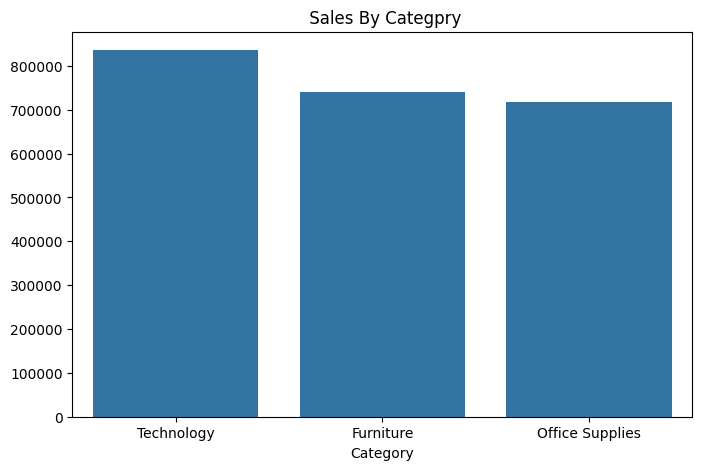

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x = Category.index,
            y= Category.values)
plt.title(" Sales By Categpry")

plt.savefig(
    "images/sales_by_category.png",
    bbox_inches="tight"
)
plt.show()

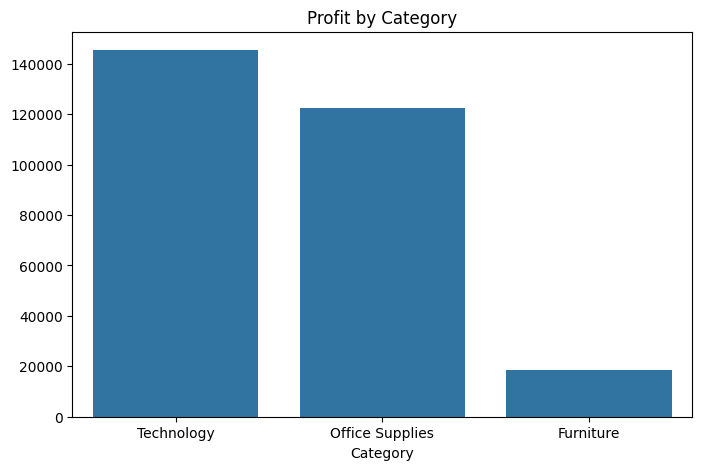

In [29]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.savefig(
    "images/sales_by_category.png",
    bbox_inches="tight"
)

plt.savefig(
    "images/profit_by_category.png",
    bbox_inches="tight"
)

plt.title("Profit by Category")
plt.show()

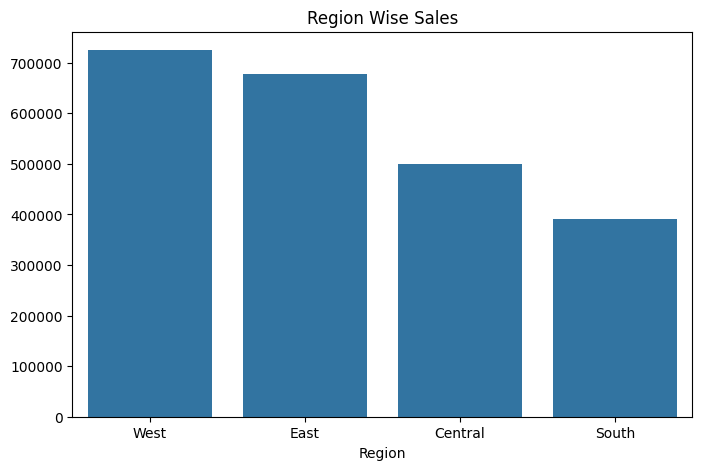

In [28]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.savefig(
    "images/sales_by_profit.png",
    bbox_inches="tight"
)



plt.title("Region Wise Sales")
plt.show()

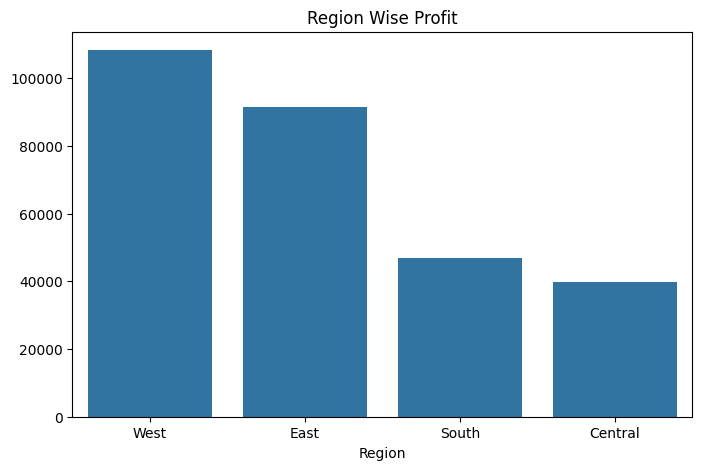

In [25]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)

plt.title("Region Wise Profit")
plt.show()

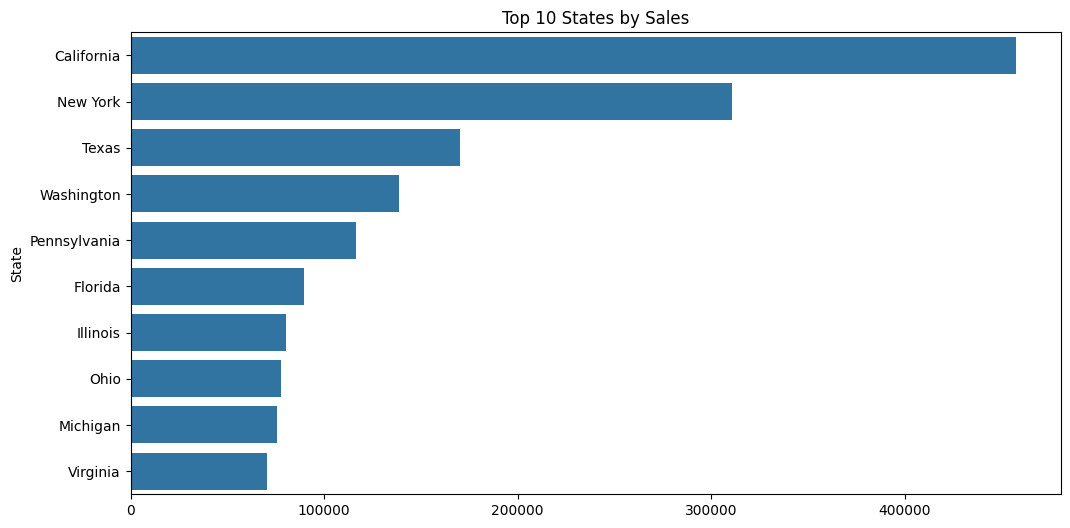

In [30]:
top_states = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.savefig(
    "images/top_states.png",
    bbox_inches="tight"
)


plt.title("Top 10 States by Sales")
plt.show()

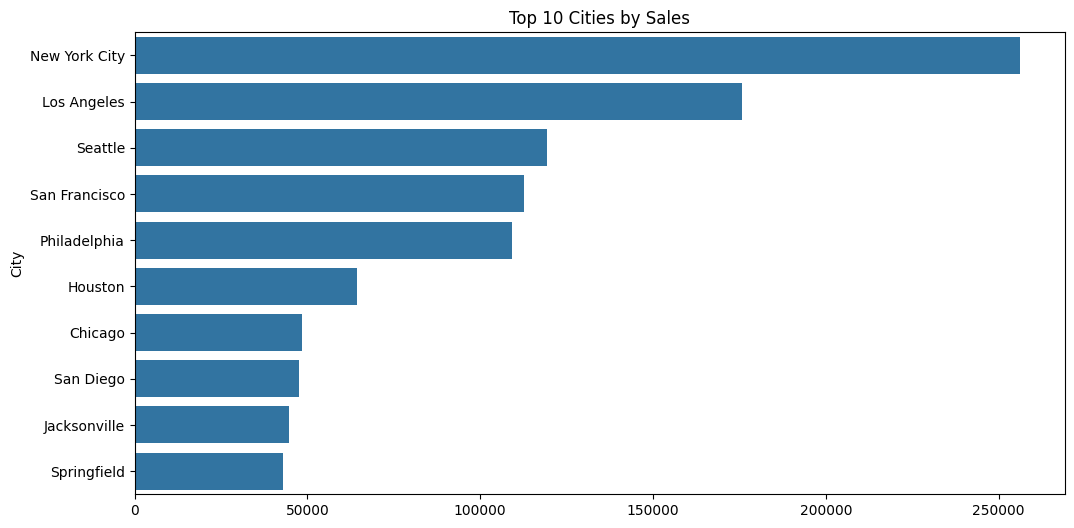

In [31]:
top_cities = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.savefig(
    "images/Top_city.png",
    bbox_inches="tight"
)

plt.title("Top 10 Cities by Sales")
plt.show()

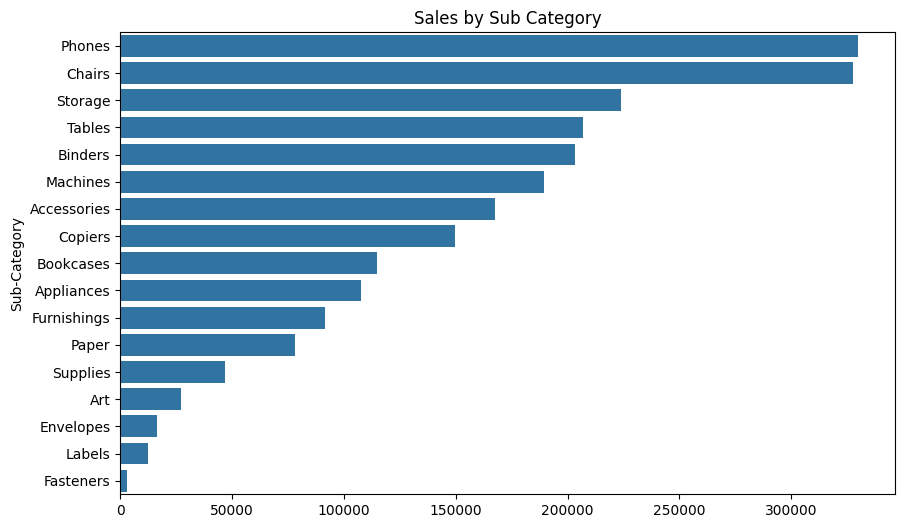

In [34]:
top_sub = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sub.values,
    y=top_sub.index
)

plt.title("Sales by Sub Category")
plt.show()

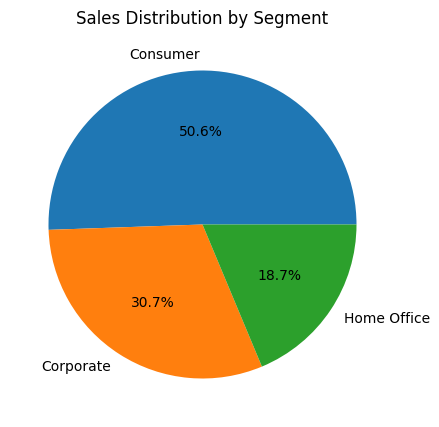

In [35]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Segment")

plt.show()

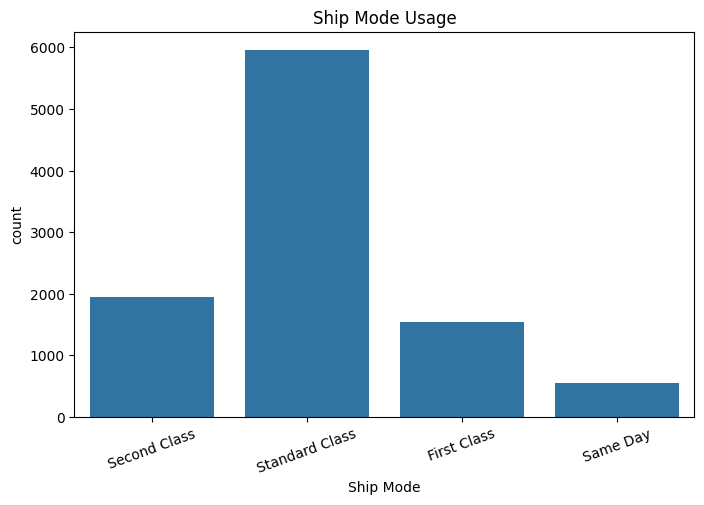

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Ship Mode",
    data=df
)

plt.xticks(rotation=20)

plt.title("Ship Mode Usage")

plt.show()

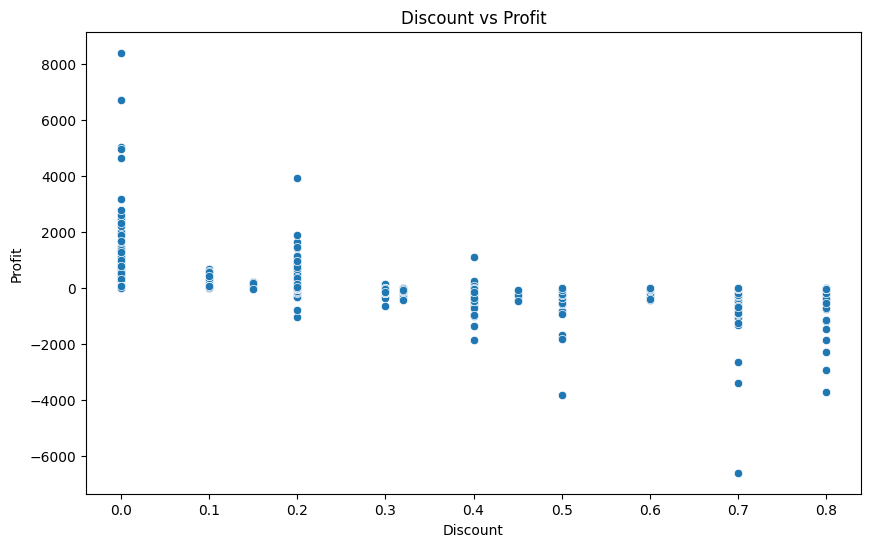

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Discount",
    y="Profit",
    data=df
)

plt.title("Discount vs Profit")

plt.show()

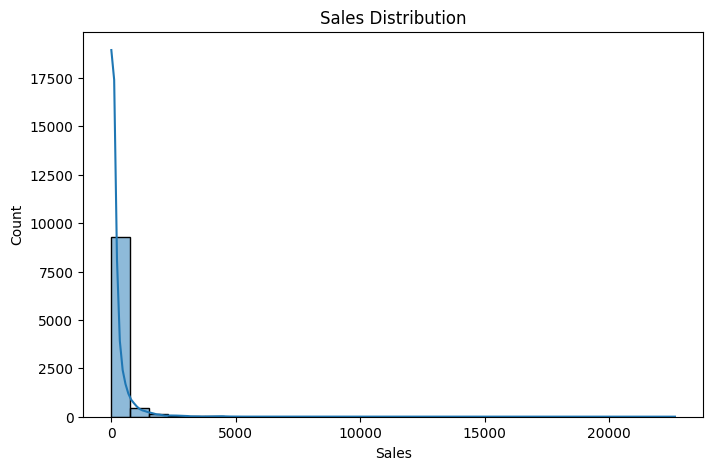

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=30,
    kde=True
)

plt.title("Sales Distribution")

plt.show()

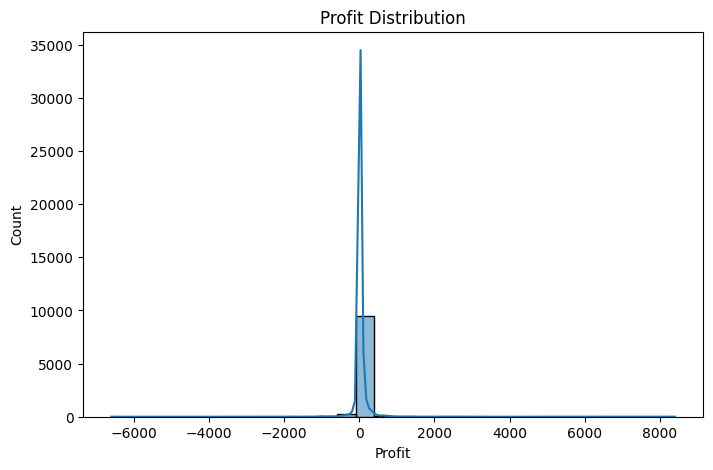

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Profit"],
    bins=30,
    kde=True
)

plt.title("Profit Distribution")

plt.show()

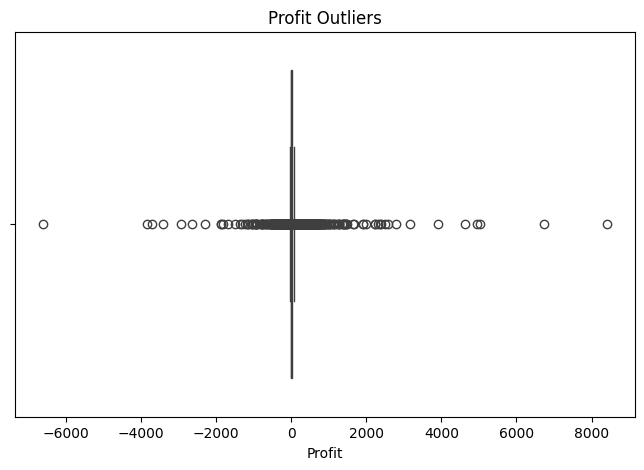

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Profit"]
)

plt.title("Profit Outliers")

plt.show()

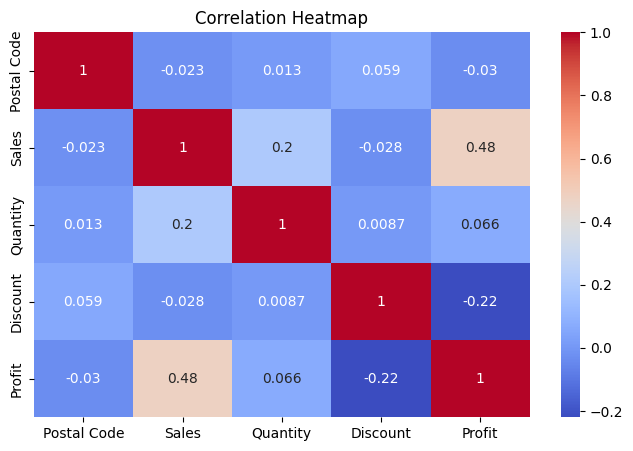

In [32]:
plt.figure(figsize=(8,5))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.savefig(
    "images/corelation_heatmap.png",
    bbox_inches="tight"
)

plt.title("Correlation Heatmap")

plt.show()

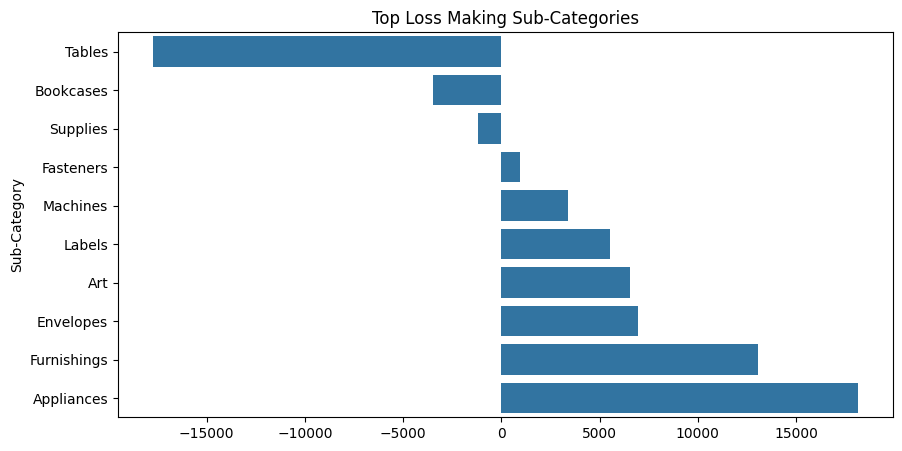

In [43]:
loss_products = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=loss_products.values,
    y=loss_products.index
)

plt.title("Top Loss Making Sub-Categories")

plt.show()

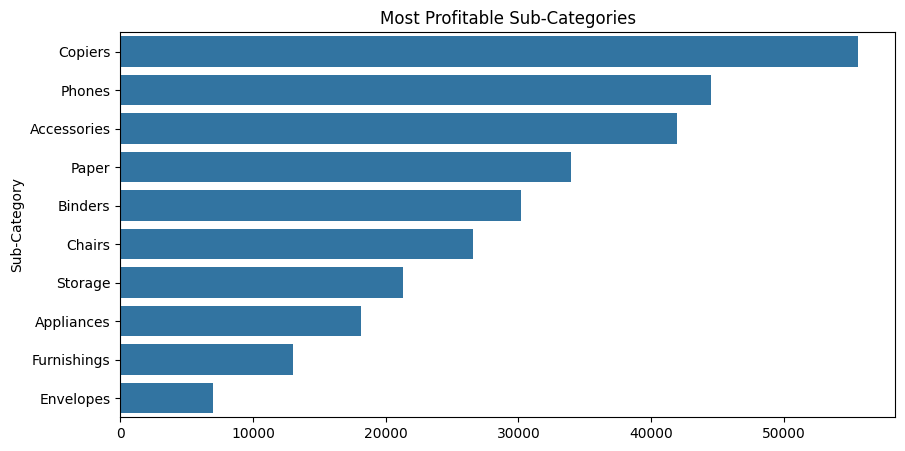

In [44]:
profit_products = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=profit_products.values,
    y=profit_products.index
)

plt.title("Most Profitable Sub-Categories")

plt.show()

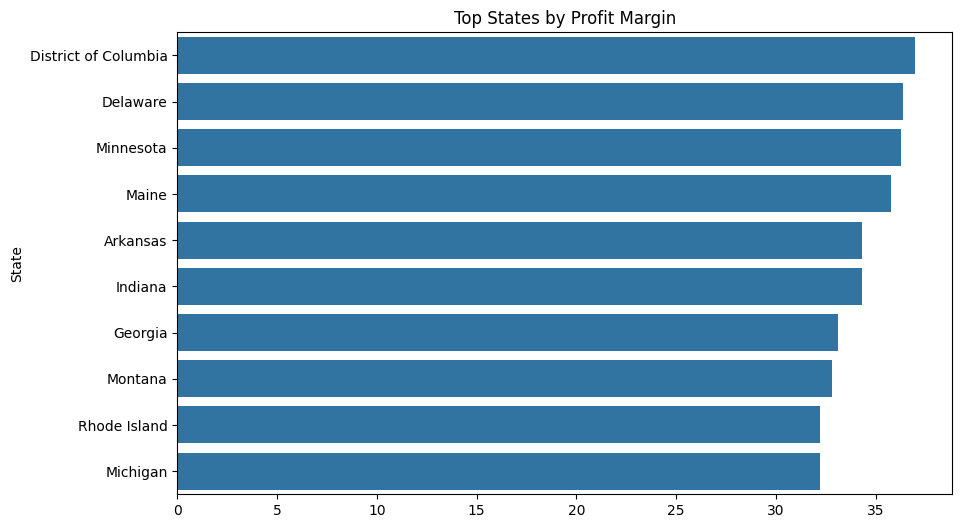

In [45]:
state_profit = (
    df.groupby("State")[["Sales","Profit"]]
    .sum()
)

state_profit["Profit_Margin"] = (
    state_profit["Profit"] /
    state_profit["Sales"]
) * 100

top_margin = (
    state_profit["Profit_Margin"]
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_margin.values,
    y=top_margin.index
)

plt.title("Top States by Profit Margin")

plt.show()

In [46]:
from scipy.stats import zscore

df["zscore"] = zscore(df["Sales"])

outliers = df[
    abs(df["zscore"]) > 3
]

print(outliers.shape)

(127, 14)


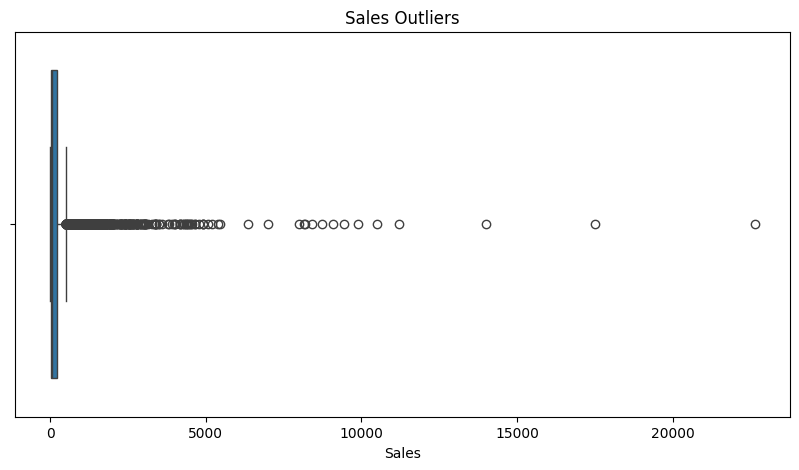

In [47]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Outliers")

plt.show()

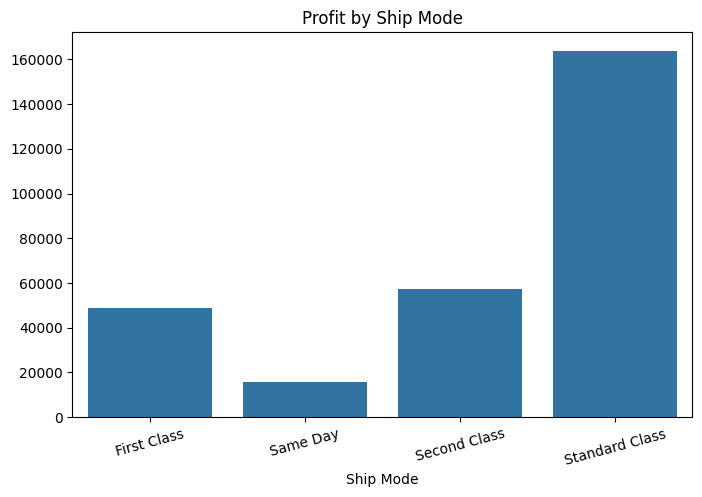

In [48]:
ship_profit = (
    df.groupby("Ship Mode")["Profit"]
    .sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=ship_profit.index,
    y=ship_profit.values
)

plt.xticks(rotation=15)

plt.title("Profit by Ship Mode")

plt.show()

In [49]:
print("TOTAL SALES :", round(df["Sales"].sum(),2))

print("TOTAL PROFIT :", round(df["Profit"].sum(),2))

print("TOTAL ORDERS :", len(df))

print("AVG SALES :", round(df["Sales"].mean(),2))

print("AVG PROFIT :", round(df["Profit"].mean(),2))

TOTAL SALES : 2296195.59
TOTAL PROFIT : 286241.42
TOTAL ORDERS : 9977
AVG SALES : 230.15
AVG PROFIT : 28.69


In [50]:
corr = df[
    ["Sales","Quantity","Discount","Profit"]
].corr()

print(corr)

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200722 -0.028311  0.479067
Quantity  0.200722  1.000000  0.008678  0.066211
Discount -0.028311  0.008678  1.000000 -0.219662
Profit    0.479067  0.066211 -0.219662  1.000000
